In [3]:
using LinearAlgebra
using Distributions
using Plots
using Statistics
using Parameters
using Random

Random.seed!(123)

println("Packages loaded successfully")

Packages loaded successfully


## The Small Open Economy New Keynesian Model

New Keynesian model for a small open economy from **Galí (2015, Chapter 7)**. The model consists of:

**1. Dynamic IS Equation (Aggregate Demand):**
$$\tilde{y}_t = E_t\{\tilde{y}_{t+1}\} - \frac{1}{\sigma_\alpha}(i_t - E_t\{\pi_{H,t+1}\} - r_t^n) \ (38) $$ 

Output gap depends on expected future output and the real interest rate gap (nominal rate minus expected inflation minus natural rate).

**2. New Keynesian Phillips Curve (Aggregate Supply):**
$$\pi_{H,t} = \beta E_t\{\pi_{H,t+1}\} + \kappa_\alpha \tilde{y}_t \ (37) $$ 

Domestic inflation depends on expected future inflation and the current output gap. The coefficient $\kappa_\alpha = \lambda(\sigma_\alpha + \varphi)$ reflects price stickiness.

**3. Monetary Policy Rule (Taylor Rule):**
$$i_t = \rho + \phi_\pi \pi_{H,t} + \phi_y \tilde{y}_t + v_t  \ (40) $$

The central bank sets the nominal interest rate responding to inflation and output gap, plus a monetary policy shock $v_t$.

**Natural Rate of Interest:**
$$r_t^n = \rho - \sigma_\alpha \Gamma_a(1-\rho_a)a_t + \frac{\alpha\Theta\sigma_\alpha\varphi}{\sigma_\alpha + \varphi} E_t\{\Delta y^*_{t+1}\} \ (39) $$

The natural rate (flexible-price equilibrium rate) depends on productivity shocks $a_t$ and expected world output growth $E_t\{\Delta y^*_{t+1}\}$.

## Matrix Representation

We express the system in matrix form:
$$A_0 y_t = A_1 E_t\{y_{t+1}\} + A_2 z_t + A_3$$

**Variables:**
- Endogenous: $y_t = [\tilde{y}_t, \pi_{H,t}, i_t]'$ 
- Exogenous shocks: $z_t = [a_t, v_t, y^*_t]'$

**Coefficient Matrices:**

$$A_0 = \begin{bmatrix} 
1 & 0 & \frac{1}{\sigma_\alpha} \\
-\kappa_\alpha & 1 & 0 \\
-\phi_y & -\phi_\pi & 1
\end{bmatrix}$$

$$A_1 = \begin{bmatrix} 
1 & \frac{1}{\sigma_\alpha} & 0 \\
0 & \beta & 0 \\
0 & 0 & 0
\end{bmatrix}$$

$$A_2 = \begin{bmatrix} 
\frac{\psi_a}{\sigma_\alpha} & 0 & \frac{\psi_{y^*}(\rho_{y^*}-1)}{\sigma_\alpha} \\
0 & 0 & 0 \\
0 & 1 & 0
\end{bmatrix}$$

$$A_3 = \begin{bmatrix} 
\frac{\rho}{\sigma_\alpha} \\ 
0 \\ 
\rho 
\end{bmatrix}$$

where $\psi_a = -\sigma_\alpha \Gamma_a(1-\rho_a)$ and $\psi_{y^*} = \frac{\alpha\Theta\sigma_\alpha\varphi}{\sigma_\alpha + \varphi}$.

## Parameter Calibration

**Galí (2015, Chapter 7, Section 7.5.1)**

### Calibrated Parameters

**Household Preferences:**
- $\sigma_\alpha = 1.0$ - Intertemporal elasticity of substitution (log utility)
- $\varphi = 3.0$ - Inverse Frisch elasticity of labor supply (implies elasticity of 1/3)
- $\beta = 0.99$ - Quarterly discount factor (~4% annual rate)

**Price Setting (Calvo Framework):**
- $\theta = 0.75$ - Probability of keeping prices fixed (average duration = 4 quarters)
- $\lambda = \frac{(1-\theta)(1-\beta\theta)}{\theta} \approx 0.086$ - Derived slope parameter from Calvo pricing
- $\kappa_\alpha = \lambda(\sigma_\alpha + \varphi) \approx 0.34$ - NKPC slope

**Open Economy:**
- $\alpha = 0.4$ - Import share (40% openness, matching Canada's import/GDP ratio)
- $\Gamma_a = 1.0$ - Productivity impact on natural rate
- $\Theta = 1.0$ - Terms of trade elasticity

**Monetary Policy (Taylor Rule):**
- $\phi_\pi = 1.5$ - Inflation response coefficient (Taylor principle: $\phi_\pi > 1$ ensures determinacy)
- $\phi_y = 0.125$ - Output gap response coefficient (quarterly conversion: $0.5/4$)
- $\rho = -\log(\beta) \approx 0.0101$ - Steady-state real interest rate

**Shock Processes:**
- **Productivity:** $a_t = 0.66 \, a_{t-1} + \varepsilon^a_t$, with $\sigma_a = 0.0071$
- **World output:** $y^*_t = 0.86 \, y^*_{t-1} + \varepsilon^{y^*}_t$, with $\sigma_{y^*} = 0.0078$
- **Policy shock:** $\sigma_v = 0.0025$ (25 basis points standard deviation)
- **Correlation:** $\text{corr}(\varepsilon^a_t, \varepsilon^{y^*}_t) = 0.3$


*To be refined*


In [9]:
# Household parameters
σ_α = 1.0      
φ = 3.0        
β = 0.99       

# Price stickiness
θ = 0.75       
λ = (1 - θ) * (1 - β*θ) / θ  

# Open economy
α = 0.4        
Γ_a = 1.0      
Θ = 1.0        

# Derived NKPC slope
κ_α = λ * (σ_α + φ)  

# Monetary policy (Taylor rule)
φ_π = 1.5      
φ_y = 0.5/4      
ρ = -log(β)    

# Shock persistence
ρ_a = 0.66         # Productivity AR(1) 
ρ_y_star = 0.86    # World output AR(1)

# Shock volatilities
σ_a = 0.0071       
σ_y_star = 0.0078  
σ_v = 0.0025       

# Shock correlation
ρ_corr = 0.3       

#-----------------------------------------------------------------------------------------------------------------
println("=" ^ 60)
println("\nStructural Parameters:")
println("  σ_α = $σ_α")
println("  φ = $φ (inverse Frisch)")
println("  θ = $θ (Calvo - avg price duration = $(round(1/(1-θ), digits=1)) quarters)")
println("  λ = $(round(λ, digits=4)) (derived from Calvo)")
println("  α = $α (openness)")

println("\nDerived:")
println("  κ_α = $(round(κ_α, digits=4)) (NKPC slope)")

println("\nMonetary Policy:")
println("  φ_π = $φ_π, φ_y = $φ_y")

println("\nShock Processes:")
println("  ρ_a = $ρ_a (productivity persistence)")
println("  ρ_y* = $ρ_y_star (world output persistence)")
println("  σ_a = $σ_a")
println("  σ_y* = $σ_y_star")
println("  corr(εᵃ,εʸ*) = $ρ_corr")
println("=" ^ 60)


Structural Parameters:
  σ_α = 1.0
  φ = 3.0 (inverse Frisch)
  θ = 0.75 (Calvo - avg price duration = 4.0 quarters)
  λ = 0.0858 (derived from Calvo)
  α = 0.4 (openness)

Derived:
  κ_α = 0.3433 (NKPC slope)

Monetary Policy:
  φ_π = 1.5, φ_y = 0.125

Shock Processes:
  ρ_a = 0.66 (productivity persistence)
  ρ_y* = 0.86 (world output persistence)
  σ_a = 0.0071
  σ_y* = 0.0078
  corr(εᵃ,εʸ*) = 0.3


In [11]:
# Natural rate coefficients
ψ_a = -σ_α * Γ_a * (1 - ρ_a)
ψ_y_star = (α * Θ * σ_α * φ) / (σ_α + φ)

println("\nNatural rate coefficients:")
println("  ψ_a = $(round(ψ_a, digits=4))")
println("  ψ_y* = $(round(ψ_y_star, digits=4))")

# A0: Current endogenous variables
A0 = [1.0        0.0         1/σ_α;
      -κ_α       1.0         0.0;
      -φ_y       -φ_π        1.0]

# A1: Expected future endogenous
A1 = [1.0        1/σ_α       0.0;
      0.0        β           0.0;
      0.0        0.0         0.0]

# A2: Shocks [a_t, v_t, y*_t]
A2 = [ψ_a/σ_α    0.0         (ψ_y_star * (ρ_y_star - 1))/σ_α;
      0.0        0.0         0.0;
      0.0        1.0         0.0]

# A3: Constants
A3 = [ρ/σ_α; 0.0; ρ]

#------------------------------------------------------------------------------------
println("\n" * "=" ^ 50)
println("\nA0:")
display(round.(A0, digits=4))
println("\nA1:")
display(round.(A1, digits=4))
println("\nA2:")
display(round.(A2, digits=4))
println("\nA3:")
display(round.(A3, digits=4))
println("=" ^ 50)


Natural rate coefficients:
  ψ_a = -0.34
  ψ_y* = 0.3


A0:


3×3 Matrix{Float64}:
  1.0      0.0  1.0
 -0.3433   1.0  0.0
 -0.125   -1.5  1.0


A1:


3×3 Matrix{Float64}:
 1.0  1.0   0.0
 0.0  0.99  0.0
 0.0  0.0   0.0


A2:


3×3 Matrix{Float64}:
 -0.34  0.0  -0.042
  0.0   0.0   0.0
  0.0   1.0   0.0


A3:


3-element Vector{Float64}:
 0.0101
 0.0
 0.0101

In [12]:
# Check stability
eigenvalues = eigvals(A0 \ A1)

for (i, λ) in enumerate(eigenvalues)
    println("λ_$i = $(round(λ, digits=4)) (|λ| = $(round(abs(λ), digits=4)))")
end

# For determinacy: number of eigenvalues outside unit circle 
# should equal number of forward-looking variables

λ_1 = 0.0 + 0.0im (|λ| = 0.0)
λ_2 = 0.7491 - 0.2061im (|λ| = 0.777)
λ_3 = 0.7491 + 0.2061im (|λ| = 0.777)


In [6]:
println("\n" * "=" ^ 50)
println("=" ^ 50)

# Persistence matrix
P = diagm([ρ_a, 0.0, ρ_y_star])

# Initialize
C = zeros(3, 3)
c0 = zeros(3)

try
    C = (A0 - A1*P) \ A2
    c0 = (A0 - A1) \ A3
    
    println("\n✓ Solution computed")
    
    println("\n" * "=" ^ 50)
    println("REE COEFFICIENT MATRIX C")
    println("=" ^ 50)
    display(round.(C, digits=4))
    
    println("\n" * "=" ^ 50)
    println("REE CONSTANT c0")
    println("=" ^ 50)
    display(round.(c0, digits=4))
    
    println("\n" * "=" ^ 50)
    println("IMPULSE RESPONSES (1 std dev shocks):")
    println("=" ^ 50)
    println("Productivity shock (σ_a = $σ_a):")
    println("  Output gap:    $(round(C[1,1]*σ_a, digits=6))")
    println("  Inflation:     $(round(C[2,1]*σ_a, digits=6))")
    println("  Interest rate: $(round(C[3,1]*σ_a, digits=6))")
    
    println("\nWorld output shock (σ_y* = $σ_y_star):")
    println("  Output gap:    $(round(C[1,3]*σ_y_star, digits=6))")
    println("  Inflation:     $(round(C[2,3]*σ_y_star, digits=6))")
    println("  Interest rate: $(round(C[3,3]*σ_y_star, digits=6))")
    println("=" ^ 50)
    
catch e
    println("❌ Error: ", e)
end



✓ Solution computed

REE COEFFICIENT MATRIX C


3×3 Matrix{Float64}:
 -0.3469  -1.0204  -0.0429
 -0.1191  -0.3503  -0.0147
 -0.222    0.3469  -0.0274


REE CONSTANT c0


3-element Vector{Float64}:
 -0.0
 -0.0
  0.0101


IMPULSE RESPONSES (1 std dev shocks):
Productivity shock (σ_a = 0.0071):
  Output gap:    -0.002463
  Inflation:     -0.000846
  Interest rate: -0.001576

World output shock (σ_y* = 0.0078):
  Output gap:    -0.000334
  Inflation:     -0.000115
  Interest rate: -0.000214


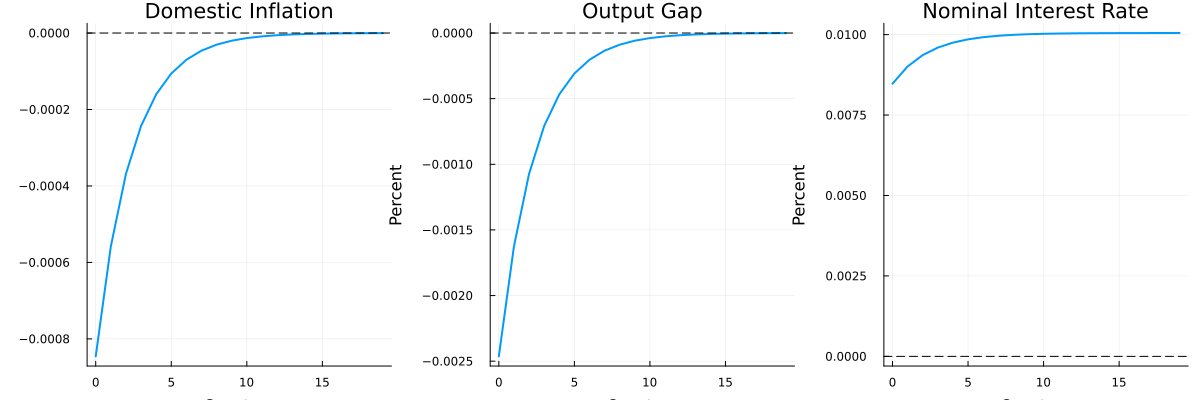

In [7]:
# Impulse Response Functions

T = 20  # 20 quarters (5 years)

# Productivity shock (1 std dev)
a_shock = zeros(T)
a_shock[1] = σ_a  # Initial shock

for t in 2:T
    a_shock[t] = ρ_a * a_shock[t-1]
end

# No policy or world shocks for now
v_shock = zeros(T)
y_star_shock = zeros(T)

# Compute REE response
Z = hcat(a_shock, v_shock, y_star_shock)
Y_REE = zeros(T, 3)

for t in 1:T
    Y_REE[t, :] = C * Z[t, :] + c0
end

p1 = plot(0:T-1, Y_REE[:, 2], 
          xlabel="Quarters", ylabel="Percent",
          linewidth=2, legend=false, 
          title="Domestic Inflation",
          grid=true)
hline!([0], linestyle=:dash, color=:black, linewidth=1)

p2 = plot(0:T-1, Y_REE[:, 1],
          xlabel="Quarters", ylabel="Percent", 
          linewidth=2, legend=false,
          title="Output Gap",
          grid=true)
hline!([0], linestyle=:dash, color=:black, linewidth=1)

p3 = plot(0:T-1, Y_REE[:, 3],
          xlabel="Quarters", ylabel="Percent",
          linewidth=2, legend=false,
          title="Nominal Interest Rate",
          grid=true)
hline!([0], linestyle=:dash, color=:black, linewidth=1)

plot(p1, p2, p3, layout=(1,3), size=(1200, 400))